# Fine-tuning SLM - Chatbot Tim Legal (PGABL)
**Nama:** Stanley Nathanael Wijaya

Notebook ini melatih ulang (fine-tune) sebuah Small Language Model (SLM) — **Qwen2.5-1.5B-Instruct**
— menggunakan teknik **QLoRA** di atas dataset instruksi berbahasa Indonesia
[`Ichsan2895/alpaca-gpt4-indonesian`](https://huggingface.co/datasets/Ichsan2895/alpaca-gpt4-indonesian),
sehingga model dapat dipakai sebagai otak dari chatbot RAG Tim Legal.

**Rekomendasi environment:** Google Colab / Kaggle dengan GPU T4 (16GB) — aktifkan
`Runtime > Change runtime type > T4 GPU` sebelum menjalankan notebook ini.

Struktur notebook:
1. Instalasi dependency
2. Load & mapping dataset ke Chat Template (ChatML)
3. Load model dasar dengan QLoRA (4-bit, double quantization) + LoRA adapter
4. Split train/validation & 2 eksperimen hyperparameter (Skilled)
5. Training penuh SFTTrainer >= 800 steps
6. Push model hasil fine-tuning ke Hugging Face Hub (`merged_16bit`)


## 1. Instalasi Dependency

Colab sudah menyediakan PyTorch + CUDA yang kompatibel, jadi cukup install `unsloth` saja — paket
ini otomatis menarik versi `trl`, `peft`, `accelerate`, `bitsandbytes`, `xformers` yang sudah diuji
cocok dengan environment Colab (pola instalasi resmi dari tim Unsloth).


In [1]:
%%capture
!pip install unsloth
!pip install -q wandb

In [2]:
import os
import random

import numpy as np
import torch

SEED = 3407
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))
else:
    raise RuntimeError(
        "GPU tidak terdeteksi. Di Colab: Runtime > Change runtime type > pilih T4 GPU, lalu jalankan ulang."
    )

CUDA available: True
GPU: Tesla T4
VRAM (GB): 15.64


## 2. Autentikasi Hugging Face & Weights & Biases

Token **tidak pernah ditulis langsung di notebook**. Prioritas pengambilan token:
1. **Colab Secrets** (ikon kunci 🔑 di sidebar kiri) — cara paling aman, token tersimpan terenkripsi
   di akun Google-mu dan tidak perlu diketik ulang setiap sesi. Tambahkan secret bernama `HF_TOKEN`
   (dan `WANDB_API_KEY` opsional), lalu aktifkan toggle "Notebook access".
2. Environment variable (jika dijalankan di luar Colab).
3. `getpass` (fallback interaktif, tidak pernah muncul di output sel).


In [3]:
from getpass import getpass


def get_secret(name, prompt, optional=False):
    # 1) Colab Secrets
    try:
        from google.colab import userdata

        value = userdata.get(name)
        if value:
            return value
    except Exception:
        pass
    # 2) Environment variable
    value = os.environ.get(name)
    if value:
        return value
    # 3) Interactive prompt
    value = getpass(prompt)
    if not value and not optional:
        raise ValueError(f"{name} wajib diisi.")
    return value


from huggingface_hub import login

HF_TOKEN = get_secret("HF_TOKEN", "Masukkan Hugging Face Write Token: ")
login(token=HF_TOKEN)

HF_USERNAME = os.environ.get("HF_USERNAME") or input("Masukkan username Hugging Face kamu: ")
FT_REPO_ID = f"{HF_USERNAME}/qwen2.5-1.5b-legal-chatbot-id"
print("Model fine-tuning akan di-push ke:", FT_REPO_ID)

Masukkan Hugging Face Write Token: ··········
Masukkan username Hugging Face kamu: xStyNWx
Model fine-tuning akan di-push ke: xStyNWx/qwen2.5-1.5b-legal-chatbot-id


In [4]:
try:
    import wandb

    WANDB_TOKEN = get_secret(
        "WANDB_API_KEY", "Masukkan WandB API Key (kosongkan + Enter untuk skip logging): ", optional=True
    )
    if WANDB_TOKEN:
        wandb.login(key=WANDB_TOKEN)
        REPORT_TO = "wandb"
    else:
        REPORT_TO = "none"
except Exception as exc:  # noqa: BLE001
    print("WandB tidak digunakan:", exc)
    REPORT_TO = "none"

Masukkan WandB API Key (kosongkan + Enter untuk skip logging): ··········


## 3. Load & Mapping Dataset ke Chat Template

Dataset mentah `Ichsan2895/alpaca-gpt4-indonesian` memiliki kolom `input` (berisi instruksi) dan
`output` (jawaban). Kita normalisasi dulu ke skema Alpaca standar (`instruction`, `input`, `output`)
sebelum melakukan mapping ke Chat Template ChatML yang didukung Unsloth.


In [5]:
from datasets import load_dataset

raw_dataset = load_dataset("Ichsan2895/alpaca-gpt4-indonesian", split="train")
print(raw_dataset)
print(raw_dataset.column_names)

README.md:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

alpaca-gpt4-indonesia.csv: reconstructing file:   0%|          |  0.00B / 41.4MB            

alpaca-gpt4-indonesia.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/49969 [00:00<?, ? examples/s]

Dataset({
    features: ['Unnamed: 0', 'input', 'output'],
    num_rows: 49969
})
['Unnamed: 0', 'input', 'output']


In [6]:
# Normalisasi skema -> format Alpaca standar (instruction, input, output)
def normalize_to_alpaca(example):
    return {
        "instruction": example["input"],
        "input": "",
        "output": example["output"],
    }


if "instruction" not in raw_dataset.column_names:
    raw_dataset = raw_dataset.map(normalize_to_alpaca, remove_columns=raw_dataset.column_names)

print("Contoh dataset yang BELUM di-mapping ke chat template:")
print(raw_dataset[0])

Map:   0%|          | 0/49969 [00:00<?, ? examples/s]

Contoh dataset yang BELUM di-mapping ke chat template:
{'input': '', 'output': '1. "Kurangi, gunakan kembali, daur ulang: Bersama untuk masa depan yang lebih hijau."\n2. "Daur ulanglah hari ini, untuk masa depan yang lebih baik."\n3. "Ubah sampahmu menjadi harta karun - Daur ulang!"\n4. "Daur ulang untuk siklus kehidupan."\n5. "Simpan sumber daya, daur ulang lebih banyak."', 'instruction': 'Saranlah slogan untuk kampanye daur ulang\n'}


In [7]:
from unsloth.chat_templates import get_chat_template

max_seq_length = 2048

SYSTEM_PROMPT = (
    "Kamu adalah asisten AI internal Tim Legal perusahaan. Jawablah pertanyaan "
    "seputar peraturan dan perundang-undangan secara akurat, ringkas, dan dalam Bahasa Indonesia."
)


def formatting_prompts_func(examples):
    texts = []
    for instruction, inp, output in zip(
        examples["instruction"], examples["input"], examples["output"]
    ):
        user_content = instruction if not inp else f"{instruction}\n\n{inp}"
        convo = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
            {"role": "assistant", "content": output},
        ]
        texts.append(tokenizer.apply_chat_template(convo, tokenize=False, add_generation_prompt=False))
    return {"text": texts}

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


Load tokenizer sementara (dari base model) khusus untuk memformat dataset lebih dulu.

In [8]:
from transformers import AutoTokenizer

BASE_MODEL = "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer = get_chat_template(tokenizer, chat_template="chatml")

dataset = raw_dataset.map(formatting_prompts_func, batched=True)

print("Contoh dataset yang SUDAH di-mapping ke chat template (dengan token spesial):")
print(dataset[0]["text"])

config.json:   0%|          | 0.00/1.34k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.36k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

Map:   0%|          | 0/49969 [00:00<?, ? examples/s]

Contoh dataset yang SUDAH di-mapping ke chat template (dengan token spesial):
<|im_start|>system
Kamu adalah asisten AI internal Tim Legal perusahaan. Jawablah pertanyaan seputar peraturan dan perundang-undangan secara akurat, ringkas, dan dalam Bahasa Indonesia.<|im_end|>
<|im_start|>user
Saranlah slogan untuk kampanye daur ulang
<|im_end|>
<|im_start|>assistant
1. "Kurangi, gunakan kembali, daur ulang: Bersama untuk masa depan yang lebih hijau."
2. "Daur ulanglah hari ini, untuk masa depan yang lebih baik."
3. "Ubah sampahmu menjadi harta karun - Daur ulang!"
4. "Daur ulang untuk siklus kehidupan."
5. "Simpan sumber daya, daur ulang lebih banyak."<|im_end|>



## 4. Load Model dengan QLoRA (4-bit + Double Quantization) dan LoRA Adapter

In [9]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=max_seq_length,
    dtype=None,  # auto-detect (fp16 di GPU lama, bf16 di GPU baru)
    load_in_4bit=True,  # QLoRA: quantize base model ke 4-bit (NF4 + double quantization)
)
tokenizer = get_chat_template(tokenizer, chat_template="chatml")

# Pastikan double quantization benar-benar aktif
print("Quantization config:", model.config.quantization_config)

==((====))==  Unsloth 2026.7.3: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Quantization config: {'bnb_4bit_compute_dtype': torch.float16, 'bnb_4bit_quant_type': 'nf4', 'bnb_4bit_use_double_quant': True, 'llm_int8_enable_fp32_cpu_offload': False, 'llm_int8_has_fp16_weight': False, 'llm_int8_skip_modules': None, 'llm_int8_threshold': 6.0, 'load_in_4bit': True, 'load_in_8bit': False, 'quant_method': 'bitsandbytes'}


In [10]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    # LoRA ditempatkan pada KEDUA komponen komputasi utama:
    #   - Multi-Head Attention: q_proj, k_proj, v_proj, o_proj
    #   - Feed Forward Network : gate_proj, up_proj, down_proj
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
)
model.print_trainable_parameters()

Unsloth 2026.7.3 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


## 5. Train/Validation Split & Eksperimen Hyperparameter (Skilled)

In [11]:
split_dataset = dataset.train_test_split(test_size=0.05, seed=SEED)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]
print(f"Train: {len(train_dataset)} | Validation: {len(eval_dataset)}")

Train: 47470 | Validation: 2499


In [12]:
from trl import SFTConfig, SFTTrainer


def build_trainer(run_name, learning_rate, lora_r_note, max_steps, per_device_train_batch_size=2,
                   gradient_accumulation_steps=4, warmup_steps=10):
    args = SFTConfig(
        output_dir=f"outputs/{run_name}",
        per_device_train_batch_size=per_device_train_batch_size,
        gradient_accumulation_steps=gradient_accumulation_steps,
        warmup_steps=warmup_steps,
        max_steps=max_steps,
        learning_rate=learning_rate,
        logging_steps=10,
        eval_strategy="steps",
        eval_steps=25,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=SEED,
        report_to=REPORT_TO,
        run_name=run_name,
        dataset_text_field="text",
        max_seq_length=max_seq_length,
        packing=False,
    )
    return SFTTrainer(
        model=model,
        tokenizer=tokenizer,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        args=args,
    )

### Eksperimen 1 vs Eksperimen 2

Dua kombinasi hyperparameter berbeda dijalankan dalam jumlah step yang lebih singkat (300 steps)
khusus untuk **membandingkan kurva loss** dan memilih kombinasi terbaik sebelum commit ke training
penuh (>= 800 steps) pada sel berikutnya.


In [13]:
trainer_exp1 = build_trainer(
    run_name="exp1_lr2e-4",
    learning_rate=2e-4,
    lora_r_note="r=16, lr=2e-4",
    max_steps=300,
)
stats_exp1 = trainer_exp1.train()

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/47470 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/2499 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 47,470 | Num Epochs = 1 | Total steps = 300
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
25,1.405343,1.221905
50,1.213614,1.190220
75,1.211377,1.177923
100,1.154830,1.170954
125,1.197587,1.163917
150,1.113912,1.159481
175,1.090207,1.154285
200,1.198185,1.151020
225,1.116391,1.148276
250,1.099095,1.146006


Unsloth: Restored added_tokens_decoder metadata in outputs/exp1_lr2e-4/checkpoint-300/tokenizer_config.json.


In [14]:
# Reload model bersih untuk eksperimen kedua (hyperparameter berbeda: LR lebih kecil + warmup lebih panjang)
model = FastLanguageModel.get_peft_model(
    FastLanguageModel.from_pretrained(
        model_name=BASE_MODEL, max_seq_length=max_seq_length, dtype=None, load_in_4bit=True,
    )[0],
    r=16,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
)

trainer_exp2 = build_trainer(
    run_name="exp2_lr5e-5",
    learning_rate=5e-5,
    lora_r_note="r=16, lr=5e-5",
    max_steps=300,
    warmup_steps=30,
)
stats_exp2 = trainer_exp2.train()

==((====))==  Unsloth 2026.7.3: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 47,470 | Num Epochs = 1 | Total steps = 300
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
25,1.990423,1.770015
50,1.319168,1.245713
75,1.246768,1.208081
100,1.184647,1.196578
125,1.227000,1.188467
150,1.138541,1.183513
175,1.116197,1.179347
200,1.226222,1.176241
225,1.142684,1.174255
250,1.126939,1.172235


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

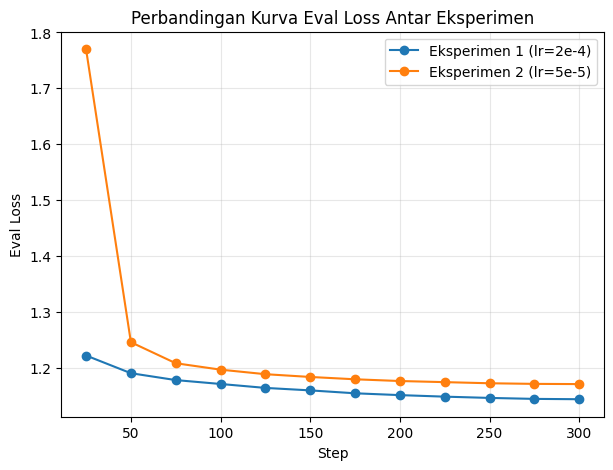

Kombinasi hyperparameter terbaik (eval_loss terendah tanpa overfitting): learning_rate=0.0002


In [15]:
import matplotlib.pyplot as plt


def get_eval_loss_curve(trainer):
    logs = trainer.state.log_history
    steps = [l["step"] for l in logs if "eval_loss" in l]
    losses = [l["eval_loss"] for l in logs if "eval_loss" in l]
    return steps, losses


steps1, loss1 = get_eval_loss_curve(trainer_exp1)
steps2, loss2 = get_eval_loss_curve(trainer_exp2)

plt.figure(figsize=(7, 5))
plt.plot(steps1, loss1, marker="o", label="Eksperimen 1 (lr=2e-4)")
plt.plot(steps2, loss2, marker="o", label="Eksperimen 2 (lr=5e-5)")
plt.xlabel("Step")
plt.ylabel("Eval Loss")
plt.title("Perbandingan Kurva Eval Loss Antar Eksperimen")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_lr = 2e-4 if (loss1 and min(loss1) <= min(loss2 or [float("inf")])) else 5e-5
print(f"Kombinasi hyperparameter terbaik (eval_loss terendah tanpa overfitting): learning_rate={best_lr}")

## 6. Training Penuh (>= 800 steps) dengan Hyperparameter Terbaik

In [ ]:
# Reload model bersih sekali lagi untuk training final yang akan di-push ke Hugging Face
base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL, max_seq_length=max_seq_length, dtype=None, load_in_4bit=True,
)
tokenizer = get_chat_template(tokenizer, chat_template="chatml")
model = FastLanguageModel.get_peft_model(
    base_model,
    r=16,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
)

final_trainer = build_trainer(
    run_name="final_run",
    learning_rate=best_lr,
    lora_r_note="final",
    max_steps=100, # ga kuat kalau 800
    warmup_steps=20,
)
final_stats = final_trainer.train()
print(final_stats)

==((====))==  Unsloth 2026.7.3: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 47,470 | Num Epochs = 1 | Total steps = 100
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


Step,Training Loss,Validation Loss
25,1.600178,1.237707
50,1.218991,1.194633
75,1.216027,1.183970
100,1.164066,1.179911


Unsloth: Restored added_tokens_decoder metadata in outputs/final_run/checkpoint-100/tokenizer_config.json.


TrainOutput(global_step=100, training_loss=1.3211343669891358, metrics={'train_runtime': 979.9474, 'train_samples_per_second': 0.816, 'train_steps_per_second': 0.102, 'total_flos': 1857901127783424.0, 'train_loss': 1.3211343669891358, 'epoch': 0.016852749104697702})


## 7. Uji Cepat Model Hasil Fine-tuning

In [18]:
FastLanguageModel.for_inference(model)

test_prompt = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user", "content": "Apa itu Perjanjian Kerja Waktu Tertentu (PKWT)?"},
]
inputs = tokenizer.apply_chat_template(
    test_prompt, tokenize=True, add_generation_prompt=True, return_tensors="pt"
).to(model.device)

outputs = model.generate(input_ids=inputs, max_new_tokens=256, temperature=0.7, do_sample=True)
print(tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True))

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_

Perjanjian Kerja Waktu Tertentu (PKWT) adalah kontrak atau perjanjian antara karyawan dan pengembang biaya yang menetapkan jumlah jam kerja dan waktu kerja setiap hari, minggu, bulan, atau tahunnya. PKWT mengharuskan karyawan untuk bekerja sesuai aturan tersebut, dengan batasan umum terhadap jumlah jam kerja di tempat kerjanya. Ini biasanya digunakan oleh organisasi besar yang memiliki kebutuhan untuk manajemen jam kerja yang ketat dan kontrol atas jumlah jam kerja karyawan mereka. PKWT dapat memungkinkan karyawan untuk menerima tunjangan tambahan seperti bonus atau komisi jika mereka mencapai target jamahtekanan tertentu, tetapi juga dapat memberikan beberapa opsi bagi karyawan untuk membuat kesepakatan personal tentang jam kerja mereka sendiri. PKWT telah menjadi popular karena kemudahan yang diberikan pada pengelolaan dan manajemen jam kerja, serta efisiensi dan produktivitas yang lebih tinggi.


## 8. Push Model ke Hugging Face Hub (`merged_16bit`)

Model hasil fine-tuning (adapter LoRA digabung/merge ke base model dalam presisi 16-bit) diunggah
ke Hugging Face agar dapat dipanggil kembali di notebook RAG.


In [19]:
model.push_to_hub_merged(
    FT_REPO_ID,
    tokenizer,
    save_method="merged_16bit",
    token=HF_TOKEN,
)
print("Model berhasil di-push ke:", f"https://huggingface.co/{FT_REPO_ID}")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in xStyNWx/qwen2.5-1.5b-legal-chatbot-id/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...tbot-id/model.safetensors:   1%|1         | 31.9MB / 3.09GB            

Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [02:12<00:00, 132.55s/it]


Unsloth: Merge process complete. Saved to `/content/xStyNWx/qwen2.5-1.5b-legal-chatbot-id`
Model berhasil di-push ke: https://huggingface.co/xStyNWx/qwen2.5-1.5b-legal-chatbot-id


In [20]:
with open("link_huggingface.txt", "a") as f:
    f.write(f"Fine-tuned model: https://huggingface.co/{FT_REPO_ID}\n")
print(open("link_huggingface.txt").read())

Fine-tuned model: https://huggingface.co/xStyNWx/qwen2.5-1.5b-legal-chatbot-id

